# Algorithmic Recourse sobre Adult Income

En este taller adaptamos el notebook de *algorithmic recourse* al dataset **UCI Adult Income** incluido en este repo. La secuencia pedagógica es:

1. cargar y limpiar el dataset real;
2. entrenar un modelo interpretable (regresión logística);
3. elegir un caso rechazado pero cercano al umbral;
4. definir restricciones de *actionability* y una función de costo;
5. buscar un recourse manual, explícito y justificable;
6. comparar alternativas, explicar por qué funciona y visualizar el cambio;
7. analizar si la recomendación sigue siendo útil en un escenario temporal adverso.

La meta no es producir la mejor solución de optimización posible, sino una recomendación **entendible, reproducible y conectada con el objetivo del taller**.

## 1. Importar librerías

In [1]:
# ============================================
# CELDA 1. IMPORTAR LIBRERÍAS
# ============================================

from pathlib import Path
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

## 2. Cargar el dataset desde la raíz del repositorio

Antes de limpiar o modelar, necesitamos leer el dataset real del proyecto. Esta celda resuelve la ruta desde la raíz del repo para que el notebook siga siendo portable y reproducible aunque se abra desde distintos directorios de trabajo.

In [2]:
# ============================================
# CELDA 2. CARGAR DATASET DESDE EL REPO
# ============================================

current_dir = Path.cwd().resolve()
candidate_roots = [current_dir, *current_dir.parents]
data_path = None

for root in candidate_roots:
    candidate = root / "data" / "archive" / "adult.csv"
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError("No se encontró data/archive/adult.csv en la raíz del repo ni en sus padres")

df_raw = pd.read_csv(data_path)

display_path = Path("data") / "archive" / "adult.csv"
print(f"Ruta usada: {display_path}")
print(f"Shape original: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
display(df_raw.head())

Ruta usada: data/archive/adult.csv
Shape original: 32,561 filas x 15 columnas


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### Preparar el dataset Adult Income

Acá dejamos explícito que el notebook trabaja con **Adult Income**, no con un dataset sintético. Limpiamos los valores faltantes codificados como `?`, construimos la variable objetivo binaria y revisamos rápidamente qué información queda disponible para el modelo interpretable.

In [3]:
# ============================================
# CELDA 3. LIMPIEZA Y VARIABLE OBJETIVO
# ============================================

df = df_raw[df_raw["workclass"] != "?"].copy()
df = df[df["occupation"] != "?"].copy()
df = df[df["native.country"] != "?"].copy()
df = df.reset_index(drop=True)

df["ingreso_alto"] = (df["income"].str.strip() == ">50K").astype(int)

print(f"Filas originales: {len(df_raw):,}")
print(f"Filas después de limpieza: {len(df):,}")
print(f"Filas removidas por '?' : {len(df_raw) - len(df):,}")
print()
print("Distribución de la variable objetivo:")
display(
    df["ingreso_alto"]
    .value_counts(normalize=True)
    .rename({0: "<=50K (0)", 1: ">50K (1)"})
    .to_frame("proporción")
)
print()
print("Vista rápida del dataset limpio:")
display(
    df[[
        "age", "education", "education.num", "hours.per.week",
        "capital.gain", "capital.loss", "ingreso_alto"
    ]].head(8)
)

Filas originales: 32,561
Filas después de limpieza: 30,162
Filas removidas por '?' : 2,399

Distribución de la variable objetivo:


,proporción
ingreso_alto,
<=50K (0),0.751078
>50K (1),0.248922



Vista rápida del dataset limpio:


,age,education,education.num,hours.per.week,capital.gain,capital.loss,ingreso_alto
0,82,HS-grad,9,18,0,4356,0
1,54,7th-8th,4,40,0,3900,0
2,41,Some-college,10,40,0,3900,0
3,34,HS-grad,9,45,0,3770,0
4,38,10th,6,40,0,3770,0
5,74,Doctorate,16,20,0,3683,1
6,68,HS-grad,9,40,0,3683,0
7,45,Doctorate,16,35,0,3004,1


### Variables observadas y actionability preliminar

Antes de entrenar el modelo, dejamos claro qué variables usaremos y cómo pensamos su grado de acción posible:

- `age`: **inmutable**. La edad aporta señal al modelo, pero no es una palanca de recourse usable en el corto plazo.
- `education.num`: **accionable**. Representa el nivel educativo en escala 1–16.
- `hours.per.week`: **accionable**. Resume carga laboral semanal.
- `capital.gain`: **accionable**. Funciona como proxy de mejora económica.
- `capital.loss`: **semi-accionable/heurística**. Se conserva para interpretar el modelo, aunque más adelante trataremos su cambio con cuidado por plausibilidad.

## 3. Entrenar un modelo interpretable

Usaremos **regresión logística** porque es una buena puerta de entrada para entender recourse.


In [4]:
feature_names = [
    "age",
    "education.num",
    "hours.per.week",
    "capital.gain",
    "capital.loss"
]

X = df[feature_names]
y = df["ingreso_alto"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

test_proba = model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)

print(f"Tamaño train: {len(X_train):,}  |  Tamaño test: {len(X_test):,}")
print()
print("AUC en test:", round(roc_auc_score(y_test, test_proba), 3))
print()
print("Reporte de clasificación:")
print(classification_report(y_test, test_pred, target_names=["<=50K", ">50K"]))


Tamaño train: 22,621  |  Tamaño test: 7,541

AUC en test: 0.839

Reporte de clasificación:
              precision    recall  f1-score   support

       <=50K       0.83      0.95      0.89      5664
        >50K       0.74      0.40      0.52      1877

    accuracy                           0.82      7541
   macro avg       0.78      0.68      0.70      7541
weighted avg       0.81      0.82      0.79      7541



## 4. Interpretar el modelo

Aquí miramos qué variables empujan hacia la aprobación y cuáles hacia el rechazo.


In [5]:
coef_df = pd.DataFrame({
    "feature":     feature_names,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

print("Coeficientes del modelo (ordenados de mayor a menor):")
display(coef_df)

# ── Pasos significativos por variable ───────────────────────────────────────
# Representan un cambio mínimo realista que una persona podría hacer
meaningful_steps = {
    "age":            1,      # 1 año más (inmutable: no decrece)
    "education.num":  1,      # subir un nivel educativo
    "hours.per.week": 5,      # 5 horas más por semana
    "capital.gain":   500,    # 500 USD más de ganancia de capital
    "capital.loss":   500     # 500 USD más de pérdida (en este modelo, el coeficiente es positivo)
}

rows = []
for f, beta in zip(feature_names, model.coef_[0]):
    step = meaningful_steps[f]
    odds_multiplier = np.exp(beta * step)
    rows.append({
        "feature":                f,
        "step_used":              step,
        "beta":                   round(beta, 4),
        "odds_multiplier_for_step": round(odds_multiplier, 4)
    })

interpret_df = pd.DataFrame(rows).sort_values("beta", ascending=False)
print()
print("Impacto de un paso significativo por variable:")
display(interpret_df)

print()
print("Lectura rápida:")
print("- Coeficiente POSITIVO → subir esa variable AUMENTA la probabilidad de ganar >50K.")
print("- Coeficiente NEGATIVO → subir esa variable REDUCE la probabilidad de ganar >50K.")
print("- odds_multiplier > 1  → el paso multiplica los odds a favor de >50K.")
print("- odds_multiplier < 1  → el paso reduce los odds a favor de >50K.")


Coeficientes del modelo (ordenados de mayor a menor):


,feature,coefficient
1,education.num,0.313728
0,age,0.043114
2,hours.per.week,0.038951
4,capital.loss,0.000680
3,capital.gain,0.000325



Impacto de un paso significativo por variable:


,feature,step_used,beta,odds_multiplier_for_step
1,education.num,1,0.3137,1.3685
0,age,1,0.0431,1.0441
2,hours.per.week,5,0.0390,1.2150
4,capital.loss,500,0.0007,1.4046
3,capital.gain,500,0.0003,1.1766



Lectura rápida:
- Coeficiente POSITIVO → subir esa variable AUMENTA la probabilidad de ganar >50K.
- Coeficiente NEGATIVO → subir esa variable REDUCE la probabilidad de ganar >50K.
- odds_multiplier > 1  → el paso multiplica los odds a favor de >50K.
- odds_multiplier < 1  → el paso reduce los odds a favor de >50K.


### Interpretación de los coeficientes

- education.num tiene el coeficiente más alto: cada nivel educativo adicional multiplica los odds de ganar >50K por un factor considerable. Es la variable más poderosa y accionable.
- hours.per.week y age también contribuyen positivamente, aunque con menor magnitud.
- capital.gain tiene coeficiente positivo pequeño pero puede tener efecto si el valor es muy alto.
- capital.loss tiene coeficiente positivo pequeño también (en este modelo, capital loss tiene correlación con actividad de inversión).

## 5. Elegir un caso rechazado para hacer recourse

En lugar de fijar un índice arbitrario, elegimos un caso realmente útil para el taller: una persona **rechazada por el modelo, pero muy cerca del umbral**. Eso permite mostrar un recourse corto, interpretable y alineado con la idea de “qué debería cambiar para cruzar la frontera de decisión”.

In [6]:
# ============================================
# CELDA 5. SELECCIONAR CASO RECHAZADO CERCANO AL UMBRAL
# ============================================

test_results = X_test.copy()
test_results["true_label"] = y_test.values
test_results["pred_prob"] = test_proba
test_results["pred_label"] = test_pred

action_margin = 0.5 - test_results["pred_prob"]

actionable_preview = (
    test_results[test_results["pred_label"] == 0]
    .assign(distance_to_threshold=action_margin[test_results["pred_label"] == 0])
    .sort_values(["distance_to_threshold", "pred_prob"], ascending=[True, False])
)

print("Casos rechazados más cercanos al umbral de decisión:")
display(actionable_preview.head(10))

persona_index = actionable_preview.index[0]
persona = actionable_preview.loc[persona_index, feature_names].copy()
current_prob = float(model.predict_proba(pd.DataFrame([persona[feature_names]]))[0, 1])

print(f"Caso seleccionado: índice {persona_index}")
print("Motivo: es el rechazado más cercano al umbral y permite un recourse pedagógico con pocos cambios.")
display(persona.to_frame(name="valor_actual"))

print(f"Probabilidad actual de ganar >50K: {current_prob:.4f}")
print(f"Margen hasta el umbral 0.50: {0.5 - current_prob:.4f}")
print("Predicción actual: RECHAZADO (<=50K)")

Casos rechazados más cercanos al umbral de decisión:


,age,education.num,hours.per.week,capital.gain,capital.loss,true_label,pred_prob,pred_label,distance_to_threshold
108,49,9,40,0,2377,1,0.499427,0,0.000573
23359,32,14,60,0,0,1,0.499314,0,0.000686
5628,51,13,47,0,0,1,0.499080,0,0.000920
17107,50,14,40,0,0,0,0.498569,0,0.001431
17642,50,14,40,0,0,1,0.498569,0,0.001431
9585,61,10,60,0,0,1,0.498161,0,0.001839
2575,24,10,40,7298,0,1,0.498103,0,0.001897
3693,68,9,40,2414,0,0,0.496737,0,0.003263
12708,29,15,55,0,0,0,0.496721,0,0.003279
11243,39,13,60,0,0,1,0.496331,0,0.003669


Caso seleccionado: índice 108
Motivo: es el rechazado más cercano al umbral y permite un recourse pedagógico con pocos cambios.


,valor_actual
age,49
education.num,9
hours.per.week,40
capital.gain,0
capital.loss,2377


Probabilidad actual de ganar >50K: 0.4994
Margen hasta el umbral 0.50: 0.0006
Predicción actual: RECHAZADO (<=50K)


## 6. Definir acción, restricciones y costo

Esta es la médula del recourse: no todo se puede cambiar, no todo cambia en cualquier dirección y no todo cuesta lo mismo.


In [7]:
# ============================================
# CELDA 6. DEFINIR REGLAS DE ACTIONABILITY
# ============================================

feature_labels = {
    "age": "Edad",
    "education.num": "Nivel educativo",
    "hours.per.week": "Horas trabajadas por semana",
    "capital.gain": "Ganancias de capital",
    "capital.loss": "Pérdidas de capital"
}

coef_map = dict(zip(feature_names, model.coef_[0]))

# Regla general:
# - age: inmutable
# - education.num: accionable, solo aumenta
# - hours.per.week: accionable, solo aumenta
# - capital.gain: accionable, solo aumenta
# - capital.loss: en versión base se deja fuera por menor interpretabilidad;
#   en versión extendida se puede activar si ayuda a cruzar el umbral.

immutable_features = ["age"]

gain_q99 = float(np.ceil(df["capital.gain"].quantile(0.99) / 500) * 500)
loss_q99 = float(np.ceil(df["capital.loss"].quantile(0.99) / 500) * 500)

# Etapa 1: reglas más realistas
actionable_features_core = {
    "education.num": {
        "direction": "increase",
        "step": 1,
        "max_change": 6,
        "min_value": int(df["education.num"].min()),
        "max_value": int(df["education.num"].max()),
        "unit_cost": 3.0,
        "justification": "Aumentar nivel educativo requiere tiempo/esfuerzo"
    },
    "hours.per.week": {
        "direction": "increase",
        "step": 5,
        "max_change": 30,
        "min_value": int(df["hours.per.week"].min()),
        "max_value": min(80, int(df["hours.per.week"].max())),
        "unit_cost": 1.0,
        "justification": "Trabajar más horas es accionable, pero con costo moderado"
    },
    "capital.gain": {
        "direction": "increase",
        "step": 500,
        "max_change": max(5000, gain_q99),
        "min_value": int(df["capital.gain"].min()),
        "max_value": int(max(gain_q99, df["capital.gain"].max())),
        "unit_cost": 2.0,
        "justification": "Puede aumentar, pero no siempre es fácil ni inmediato"
    }
}

# Etapa 2: búsqueda extendida
# Si capital.loss tiene coeficiente positivo, subirla ayuda al modelo,
# aunque como recomendación humana es menos intuitiva. Se deja como plan B.
actionable_features_extended = dict(actionable_features_core)

if coef_map.get("capital.loss", 0) > 0:
    actionable_features_extended["capital.loss"] = {
        "direction": "increase",
        "step": 500,
        "max_change": max(3000, loss_q99),
        "min_value": int(df["capital.loss"].min()),
        "max_value": int(max(loss_q99, df["capital.loss"].max())),
        "unit_cost": 4.0,
        "justification": "Solo en búsqueda extendida: útil para el modelo, menos interpretable"
    }

# Se deja esta variable para compatibilidad con celdas posteriores del notebook.
actionable_features = actionable_features_core

rules_rows = []
for f, cfg in actionable_features_core.items():
    rules_rows.append({
        "feature": f,
        "nombre": feature_labels.get(f, f),
        "valor_actual": float(persona[f]),
        "direction": cfg["direction"],
        "step": cfg["step"],
        "max_change": cfg["max_change"],
        "min_value": cfg["min_value"],
        "max_value": cfg["max_value"],
        "unit_cost": cfg["unit_cost"],
        "modo": "core",
        "justificación": cfg["justification"]
    })

for f, cfg in actionable_features_extended.items():
    if f not in actionable_features_core:
        rules_rows.append({
            "feature": f,
            "nombre": feature_labels.get(f, f),
            "valor_actual": float(persona[f]),
            "direction": cfg["direction"],
            "step": cfg["step"],
            "max_change": cfg["max_change"],
            "min_value": cfg["min_value"],
            "max_value": cfg["max_value"],
            "unit_cost": cfg["unit_cost"],
            "modo": "extendido",
            "justificación": cfg["justification"]
        })

rules_df = pd.DataFrame(rules_rows)

print("Variables inmutables:", immutable_features)
print("\nReglas de actionability:")
display(rules_df)


Variables inmutables: ['age']

Reglas de actionability:


,feature,nombre,valor_actual,direction,step,max_change,min_value,max_value,unit_cost,modo,justificación
0,education.num,Nivel educativo,9.0,increase,1,6.0,1,16,3.0,core,Aumentar nivel educativo requiere tiempo/esfuerzo
1,hours.per.week,Horas trabajadas por semana,40.0,increase,5,30.0,1,80,1.0,core,"Trabajar más horas es accionable, pero con cos..."
2,capital.gain,Ganancias de capital,0.0,increase,500,15500.0,0,99999,2.0,core,"Puede aumentar, pero no siempre es fácil ni in..."
3,capital.loss,Pérdidas de capital,2377.0,increase,500,3000.0,0,4356,4.0,extendido,Solo en búsqueda extendida: útil para el model...


## Definición de reglas de *actionability*

En esta sección se fija el marco metodológico del *recourse*: **qué se puede cambiar, en qué dirección, con qué granularidad y con qué costo**. El punto clave es que una recomendación no debe ser solamente eficaz para el modelo, sino también razonable desde el punto de vista humano e interpretable para quien la lee.

### Variables inmutables

La variable `age` se considera **inmutable**. Puede influir en la predicción, pero no es admisible que el sistema la use como palanca de intervención. Por eso se excluye del espacio de búsqueda.

### Variables accionables principales

La búsqueda base (`core`) permite modificar solo variables con una interpretación relativamente clara:

- `education.num`: solo puede **aumentar**, porque un mayor nivel educativo puede mejorar la probabilidad predicha y no tendría sentido recomendar una disminución.
- `hours.per.week`: solo puede **aumentar**, bajo la idea de mayor dedicación laboral.
- `capital.gain`: solo puede **aumentar**, como una proxy de mejora económica.

Para cada variable se define:

- **`direction`**: dirección admisible del cambio.
- **`step`**: tamaño mínimo del cambio evaluado por la búsqueda.
- **`max_change`**: límite máximo respecto al valor original.
- **`min_value` / `max_value`**: cotas válidas observadas en los datos.
- **`unit_cost`**: costo por unidad de cambio, usado para priorizar recomendaciones más plausibles.

### Búsqueda extendida

Además se define una versión `extended` del conjunto de reglas. Si el coeficiente de `capital.loss` en la regresión logística resulta positivo, se habilita esta variable como apoyo en una segunda etapa de búsqueda. Esto no implica que sea la recomendación más intuitiva desde el punto de vista humano; solo significa que el modelo la está utilizando como señal favorable y, por tanto, puede servir para obtener un primer recourse factible sin modificar las celdas 2–5.

### Costo e interpretabilidad

La construcción del costo refleja que no todos los cambios son igual de fáciles:

- subir el nivel educativo tiene un costo alto;
- aumentar horas de trabajo tiene un costo moderado;
- aumentar `capital.gain` tiene un costo intermedio;
- `capital.loss`, cuando aparece en modo extendido, recibe una penalización mayor por ser menos interpretable.

Con esto, la salida no solo buscará cambios que crucen el umbral del modelo, sino que preferirá alternativas **más escasas, más baratas y más comprensibles**.


## 7. Buscar recourse por fuerza bruta explicable

La estrategia aquí es deliberadamente docente: búsqueda por grilla. No es la más elegante para producción, pero sí una de las más transparentes.


In [8]:
# ============================================
# CELDA 7. FUNCIONES DE RECOURSE
# ============================================

def build_candidate_values(current_value, cfg):
    step = cfg["step"]
    max_change = cfg["max_change"]

    if cfg["direction"] == "increase":
        upper = min(current_value + max_change, cfg["max_value"])
        values = np.arange(current_value, upper + 1e-9, step)
    elif cfg["direction"] == "decrease":
        lower = max(current_value - max_change, cfg["min_value"])
        values = np.arange(lower, current_value + 1e-9, step)
    else:
        raise ValueError(f"Dirección no soportada: {cfg['direction']}")

    values = np.round(values, 6)
    return sorted(set(values))


def recourse_cost(original, candidato, actionable_features, sparsity_weight=0.5):
    total = 0.0
    detail = {}
    changed_features = []

    for f, cfg in actionable_features.items():
        delta = float(candidato[f] - original[f])

        if abs(delta) < 1e-9:
            detail[f] = 0.0
            continue

        if cfg["direction"] == "increase" and delta < 0:
            return np.inf, {}, []
        if cfg["direction"] == "decrease" and delta > 0:
            return np.inf, {}, []

        steps_used = abs(delta) / cfg["step"]
        feature_cost = steps_used * cfg["unit_cost"]

        detail[f] = round(feature_cost, 4)
        total += feature_cost
        changed_features.append(f)

    sparsity_penalty = sparsity_weight * len(changed_features)
    detail["sparsity_penalty"] = round(sparsity_penalty, 4)
    total += sparsity_penalty

    return round(total, 4), detail, changed_features


def find_recourse(persona_row, model, feature_names, actionable_features, threshold=0.50):
    value_grid = {
        f: build_candidate_values(float(persona_row[f]), cfg)
        for f, cfg in actionable_features.items()
    }

    candidates = []
    best_partial = None

    for values in product(*[value_grid[f] for f in actionable_features.keys()]):
        candidato = persona_row.copy()

        for f, v in zip(actionable_features.keys(), values):
            candidato[f] = v

        x_candidato = pd.DataFrame([candidato[feature_names]])
        prob = float(model.predict_proba(x_candidato)[0, 1])

        total_cost, cost_detail, changed_features = recourse_cost(
            original=persona_row,
            candidato=candidato,
            actionable_features=actionable_features,
            sparsity_weight=0.5
        )

        info = {
            "prob_approve": round(prob, 4),
            "total_cost": total_cost,
            "candidate": candidato.copy(),
            "cost_detail": cost_detail,
            "n_changed_features": len(changed_features),
            "changed_features": changed_features
        }

        if (best_partial is None) or (prob > best_partial["prob_approve"]):
            best_partial = info

        if prob >= threshold:
            candidates.append(info)

    if len(candidates) == 0:
        return None, [], best_partial

    candidates = sorted(
        candidates,
        key=lambda x: (x["total_cost"], x["n_changed_features"], -x["prob_approve"])
    )

    return candidates[0], candidates, best_partial


# Probabilidad actual del caso seleccionado en la celda 5
current_prob = float(model.predict_proba(pd.DataFrame([persona[feature_names]]))[0, 1])
print(f"Probabilidad actual del caso seleccionado: {current_prob:.4f}")

# Etapa 1: búsqueda core
best_recourse, all_candidates, best_partial = find_recourse(
    persona_row=persona,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features_core,
    threshold=0.50
)

search_mode = "core"
actionable_features = actionable_features_core

# Etapa 2: si no alcanza, ampliar sin tocar celdas 2–5
if best_recourse is None:
    best_recourse, all_candidates, best_partial = find_recourse(
        persona_row=persona,
        model=model,
        feature_names=feature_names,
        actionable_features=actionable_features_extended,
        threshold=0.50
    )
    search_mode = "extendido"
    actionable_features = actionable_features_extended

print(f"\nModo de búsqueda usado: {search_mode}")
print("Número de soluciones de recourse encontradas:", len(all_candidates))

if best_recourse is None:
    print("\nNo se encontró recourse que cruce el umbral de 0.50.")
    print("Mejor candidato parcial encontrado:")
    print({
        "prob_approve": best_partial["prob_approve"],
        "total_cost": best_partial["total_cost"],
        "changed_features": best_partial["changed_features"]
    })
else:
    print("\nMejor solución encontrada:")
    print({
        "prob_approve": best_recourse["prob_approve"],
        "total_cost": best_recourse["total_cost"],
        "n_changed_features": best_recourse["n_changed_features"],
        "changed_features": best_recourse["changed_features"],
        "cost_detail": best_recourse["cost_detail"]
    })


Probabilidad actual del caso seleccionado: 0.4994

Modo de búsqueda usado: core
Número de soluciones de recourse encontradas: 1567

Mejor solución encontrada:
{'prob_approve': 0.548, 'total_cost': 1.5, 'n_changed_features': 1, 'changed_features': ['hours.per.week'], 'cost_detail': {'education.num': 0.0, 'hours.per.week': 1.0, 'capital.gain': 0.0, 'sparsity_penalty': 0.5}}


## Funciones de *recourse* y lectura de los resultados

En esta sección se implementa el motor manual de recourse mediante una **búsqueda por fuerza bruta explicable**. La idea no es optimizar computacionalmente el problema, sino mostrar con transparencia cómo se construyen y evalúan las alternativas.

### Lógica general del procedimiento

1. Para cada variable accionable, se genera una grilla de valores permitidos según sus restricciones.
2. Luego se forman todas las combinaciones posibles entre esos valores.
3. Cada combinación se evalúa con el modelo entrenado.
4. Se calcula su costo total.
5. Se conservan las soluciones que superan el umbral de aprobación.
6. Si ninguna lo supera, se conserva al menos el mejor candidato parcial para que el notebook siga siendo interpretable.

### `build_candidate_values`

Esta función construye el conjunto de valores factibles para una variable concreta a partir de cuatro ideas: dirección permitida, tamaño del paso, máximo cambio admisible y límites globales. Así se evita explorar recomendaciones imposibles o arbitrarias.

### `recourse_cost`

La función de costo suma dos componentes:

- **costo por magnitud de cambio**, calculado a partir del número de pasos realizados y del `unit_cost` de cada variable;
- **penalización por esparsidad**, que castiga cambiar demasiadas variables al mismo tiempo.

Con ello se favorecen recomendaciones más económicas y más simples de comunicar.

### `find_recourse`

Esta es la función principal. Recorre todas las combinaciones factibles, calcula su probabilidad de aprobación y ordena las soluciones usando tres criterios:

1. menor costo total;
2. menor número de variables modificadas;
3. mayor probabilidad predicha.

Además, la búsqueda se realiza en dos etapas:

- **modo `core`**: usa solo variables más interpretables;
- **modo `extendido`**: amplía el espacio de búsqueda si el modo base no encuentra una solución que cruce el umbral.

Ese diseño permite cumplir con dos objetivos a la vez: mantener el recourse razonable y, al mismo tiempo, asegurar que el notebook produzca un resultado útil sin alterar las celdas 2–5.


## 8. Mostrar el recourse de forma interpretable

In [9]:
# ============================================
# CELDA 8. RESUMEN HUMANO DEL RECOURSE
# ============================================

def human_change_text(feature, old, new):
    label = feature_labels.get(feature, feature)
    delta = float(new - old)

    if abs(delta) < 1e-9:
        return None

    if delta > 0:
        return f"{label}: subir de {old} a {new} (+{round(delta, 3)})"
    else:
        return f"{label}: bajar de {old} a {new} ({round(delta, 3)})"


if best_recourse is None:
    candidato = best_partial["candidate"]

    summary_rows = []
    for f in feature_names:
        summary_rows.append({
            "feature": f,
            "nombre": feature_labels.get(f, f),
            "original": float(persona[f]),
            "recommended": float(candidato[f]),
            "delta": round(float(candidato[f] - persona[f]), 4)
        })

    summary_df = pd.DataFrame(summary_rows)
    changed_df = summary_df[summary_df["delta"] != 0].copy()

    print("No se encontró recourse completo bajo las reglas actuales.")
    print("Sin embargo, este fue el mejor cambio parcial encontrado:")
    display(changed_df if len(changed_df) > 0 else summary_df)

    print("\nProbabilidad original:",
          round(float(model.predict_proba(pd.DataFrame([persona[feature_names]]))[0, 1]), 4))
    print("Mejor probabilidad alcanzada:",
          round(float(model.predict_proba(pd.DataFrame([candidato[feature_names]]))[0, 1]), 4))
    print("Costo total:", best_partial["total_cost"])

    changes_text = []
    for f in feature_names:
        txt = human_change_text(f, persona[f], candidato[f])
        if txt is not None:
            changes_text.append(txt)

    if len(changes_text) > 0:
        print("\nInterpretación simple:")
        print("Para acercar el caso al lado positivo del modelo, los cambios más útiles fueron:")
        for t in changes_text:
            print("-", t)

else:
    candidato = best_recourse["candidate"]

    summary_rows = []
    for f in feature_names:
        summary_rows.append({
            "feature": f,
            "nombre": feature_labels.get(f, f),
            "original": float(persona[f]),
            "recommended": float(candidato[f]),
            "delta": round(float(candidato[f] - persona[f]), 4)
        })

    summary_df = pd.DataFrame(summary_rows)
    changed_df = summary_df[summary_df["delta"] != 0].copy()

    print("Recourse encontrado correctamente.")
    print(f"Modo de búsqueda: {search_mode}")
    print()

    print("Tabla completa del antes y después:")
    display(summary_df)

    print("Variables que realmente cambiaron:")
    display(changed_df)

    original_prob = float(model.predict_proba(pd.DataFrame([persona[feature_names]]))[0, 1])
    new_prob = float(model.predict_proba(pd.DataFrame([candidato[feature_names]]))[0, 1])

    print("Probabilidad original:", round(original_prob, 4))
    print("Probabilidad con recourse:", round(new_prob, 4))
    print("Costo total:", best_recourse["total_cost"])
    print("Detalle del costo:", best_recourse["cost_detail"])

    changes_text = []
    for f in feature_names:
        txt = human_change_text(f, persona[f], candidato[f])
        if txt is not None:
            changes_text.append(txt)

    print("\nResumen simple del recourse:")
    print("El modelo inicialmente rechazaba este caso, pero encontró una combinación de cambios accionables")
    print("que lo lleva por encima del umbral de decisión.")
    print()

    print("Cambios recomendados:")
    for t in changes_text:
        print("-", t)

    print()
    print("Interpretación:")
    print("El recourse funciona porque aumenta variables con contribución positiva al modelo")
    print("sin modificar atributos inmutables como la edad.")


Recourse encontrado correctamente.
Modo de búsqueda: core

Tabla completa del antes y después:


,feature,nombre,original,recommended,delta
0,age,Edad,49.0,49.0,0.0
1,education.num,Nivel educativo,9.0,9.0,0.0
2,hours.per.week,Horas trabajadas por semana,40.0,45.0,5.0
3,capital.gain,Ganancias de capital,0.0,0.0,0.0
4,capital.loss,Pérdidas de capital,2377.0,2377.0,0.0


Variables que realmente cambiaron:


,feature,nombre,original,recommended,delta
2,hours.per.week,Horas trabajadas por semana,40.0,45.0,5.0


Probabilidad original: 0.4994
Probabilidad con recourse: 0.548
Costo total: 1.5
Detalle del costo: {'education.num': 0.0, 'hours.per.week': 1.0, 'capital.gain': 0.0, 'sparsity_penalty': 0.5}

Resumen simple del recourse:
El modelo inicialmente rechazaba este caso, pero encontró una combinación de cambios accionables
que lo lleva por encima del umbral de decisión.

Cambios recomendados:
- Horas trabajadas por semana: subir de 40 a 45 (+5.0)

Interpretación:
El recourse funciona porque aumenta variables con contribución positiva al modelo
sin modificar atributos inmutables como la edad.


## Resumen simple del *recourse* e interpretación de los resultados

La salida de esta sección traduce el resultado del motor de búsqueda a un formato entendible para una persona. El objetivo no es solo informar si se halló o no una solución, sino mostrar **qué cambió, cuánto cambió, cuánto cuesta y cómo se altera la probabilidad predicha**.

### Si existe recourse completo

Cuando el algoritmo encuentra una solución que supera el umbral de decisión, se presentan dos tablas:

- una tabla completa con el antes y el después de todas las variables del caso;
- una tabla reducida con solo las variables que realmente cambiaron.

Después se reportan cuatro elementos clave:

1. la probabilidad original del caso;
2. la probabilidad posterior al recourse;
3. el costo total;
4. el detalle del costo por variable.

Finalmente, se genera un resumen en lenguaje natural con cambios del tipo “subir de X a Y”, lo que hace la recomendación mucho más interpretable.

### Si no existe recourse completo

Si no hay una combinación factible que cruce el umbral, la celda no falla ni se queda en un mensaje vacío. En cambio, muestra el **mejor candidato parcial** encontrado dentro de las reglas definidas. Esto es útil metodológicamente porque permite discutir si el problema está en:

- un espacio de búsqueda demasiado pequeño;
- restricciones demasiado duras;
- o una persona seleccionada demasiado lejos de la frontera de decisión.

### Lectura metodológica

La interpretación de los resultados debe hacerse con cuidado. El hecho de que un cambio aumente la probabilidad predicha **no significa automáticamente** que sea una recomendación realista, ética o inmediata. Por eso el notebook separa:

- reglas más interpretables (`core`), y
- reglas ampliadas (`extendido`) cuando se necesita obtener un primer resultado demostrativo.

En otras palabras, esta sección no solo muestra una respuesta del modelo; muestra también **cómo leer críticamente esa respuesta** dentro del marco del *algorithmic recourse* explicable.


## 9. Ver varias alternativas, no solo una

Esto es importante: muchas veces hay más de una ruta para cambiar la predicción.


In [10]:
# ============================================
# CELDA 9. TOP ALTERNATIVAS DE RECOURSE
# ============================================

def build_top_recourse_table(persona_row, candidates, active_actionable_features, top_n=5):
    rows = []

    for i, c in enumerate(candidates[:top_n], start=1):
        row = {
            "rank": i,
            "prob_approve": c["prob_approve"],
            "total_cost": c["total_cost"],
            "n_changed_features": c["n_changed_features"]
        }

        for f in active_actionable_features.keys():
            row[f"{f}_new"] = c["candidate"][f]
            row[f"{f}_delta"] = round(float(c["candidate"][f] - persona_row[f]), 3)

        rows.append(row)

    return pd.DataFrame(rows)

if len(all_candidates) == 0:
    print("No hay alternativas completas que superen el umbral bajo las reglas actuales.")
else:
    active_actionable_features = actionable_features_core if search_mode == "core" else actionable_features_extended
    top_table = build_top_recourse_table(persona, all_candidates, active_actionable_features, top_n=10)
    print(f"Top de alternativas factibles en modo {search_mode}:")
    display(top_table)

Top de alternativas factibles en modo core:


,rank,prob_approve,total_cost,n_changed_features,education.num_new,education.num_delta,hours.per.week_new,hours.per.week_delta,capital.gain_new,capital.gain_delta
0,1,0.5480,1.5,1,9,0.0,45,5.0,0,0.0
1,2,0.5956,2.5,1,9,0.0,50,10.0,0,0.0
2,3,0.5400,2.5,1,9,0.0,40,0.0,500,500.0
3,4,0.6415,3.5,1,9,0.0,55,15.0,0,0.0
4,5,0.5772,3.5,1,10,1.0,40,0.0,0,0.0
5,6,0.5879,4.0,2,9,0.0,45,5.0,500,500.0
6,7,0.6850,4.5,1,9,0.0,60,20.0,0,0.0
7,8,0.5801,4.5,1,9,0.0,40,0.0,1000,1000.0
8,9,0.6341,5.0,2,9,0.0,50,10.0,500,500.0
9,10,0.6239,5.0,2,10,1.0,45,5.0,0,0.0


## 10. Explicar por qué funciona el cambio

Como el modelo es lineal en el logit, podemos descomponer el score en contribuciones por variable.


In [11]:
# ============================================
# CELDA 10. EXPLICAR CONTRIBUCIONES AL SCORE
# ============================================

coef_map = dict(zip(feature_names, model.coef_[0]))
intercept = model.intercept_[0]
selected_solution = best_recourse if best_recourse is not None else best_partial
selected_candidato = selected_solution["candidate"]


def contribution_table(row, coef_map, intercept):
    rows = []
    total = intercept

    rows.append({
        "feature": "INTERCEPT",
        "value": np.nan,
        "coefficient": np.nan,
        "contribution": intercept
    })

    for f in feature_names:
        contrib = row[f] * coef_map[f]
        total += contrib
        rows.append({
            "feature": f,
            "value": row[f],
            "coefficient": coef_map[f],
            "contribution": contrib
        })

    out = pd.DataFrame(rows)
    return out, total

before_contrib, before_score = contribution_table(persona, coef_map, intercept)
after_contrib, after_score = contribution_table(selected_candidato, coef_map, intercept)

compare = before_contrib[["feature", "contribution"]].merge(
    after_contrib[["feature", "contribution"]],
    on="feature",
    suffixes=("_before", "_after")
)
compare["delta_contribution"] = compare["contribution_after"] - compare["contribution_before"]
compare = compare.sort_values("delta_contribution", ascending=False)

print("Contribuciones antes:")
display(before_contrib)

print("Contribuciones después:")
display(after_contrib)

print("Comparación de contribuciones:")
display(compare)

print("Score logit antes:", round(before_score, 4))
print("Score logit después:", round(after_score, 4))
print()
print("Lectura:")
print("- El intercepto arranca negativo y necesita compensarse con variables favorables.")
print("- El recourse funciona cuando aumenta la contribución de variables accionables sin tocar las inmutables.")
print("- En este taller, la tabla de delta ayuda a explicar QUÉ cambio movió el caso por encima del umbral.")

Contribuciones antes:


,feature,value,coefficient,contribution
0,INTERCEPT,NaN,NaN,-8.111663
1,age,49.0,0.043114,2.112575
2,education.num,9.0,0.313728,2.823552
3,hours.per.week,40.0,0.038951,1.558057
4,capital.gain,0.0,0.000325,0.000000
5,capital.loss,2377.0,0.000680,1.615188


Contribuciones después:


,feature,value,coefficient,contribution
0,INTERCEPT,NaN,NaN,-8.111663
1,age,49.0,0.043114,2.112575
2,education.num,9.0,0.313728,2.823552
3,hours.per.week,45.0,0.038951,1.752814
4,capital.gain,0.0,0.000325,0.000000
5,capital.loss,2377.0,0.000680,1.615188


Comparación de contribuciones:


,feature,contribution_before,contribution_after,delta_contribution
3,hours.per.week,1.558057,1.752814,0.194757
0,INTERCEPT,-8.111663,-8.111663,0.000000
1,age,2.112575,2.112575,0.000000
2,education.num,2.823552,2.823552,0.000000
4,capital.gain,0.000000,0.000000,0.000000
5,capital.loss,1.615188,1.615188,0.000000


Score logit antes: -0.0023
Score logit después: 0.1925

Lectura:
- El intercepto arranca negativo y necesita compensarse con variables favorables.
- El recourse funciona cuando aumenta la contribución de variables accionables sin tocar las inmutables.
- En este taller, la tabla de delta ayuda a explicar QUÉ cambio movió el caso por encima del umbral.


## Explicación de contribuciones al *score* y lectura de los resultados

Esta sección conecta el recourse con la **mecánica interna** de la regresión logística. Antes de convertir el resultado en probabilidad, el modelo calcula un **score lineal (logit)**:

\[
	ext{score} = 	ext{intercepto} + \sum_j x_j eta_j
\]

Por eso no alcanza con decir “la probabilidad subió”: lo importante es identificar **qué variable accionable empujó el score hacia arriba**.

### Qué muestran las tablas

- **`before_contrib`**: contribución de cada variable en el caso original.
- **`after_contrib`**: contribución de cada variable luego del recourse.
- **`compare`**: diferencia entre ambos escenarios.

### Cómo leer el resultado en el taller

- Si una variable mantiene el mismo valor, su contribución no cambia.
- Si una variable accionable aumenta y su coeficiente es positivo, su contribución también aumenta.
- Cuando la suma total cruza la frontera implícita del modelo, la clasificación cambia.

Esta lectura es clave porque convierte el recourse en una explicación verificable: no solo sabemos **qué recomendar**, sino también **por qué esa recomendación altera la decisión del modelo**.

## 11. Visualización sencilla del antes y después

Cerramos la parte principal del taller con dos visualizaciones complementarias:

1. una comparación normalizada de las variables del caso antes y después del recourse;
2. una comparación de las contribuciones al score lineal.

La primera ayuda a comunicar el cambio en términos de atributos. La segunda muestra el efecto causal interno sobre la predicción del modelo.

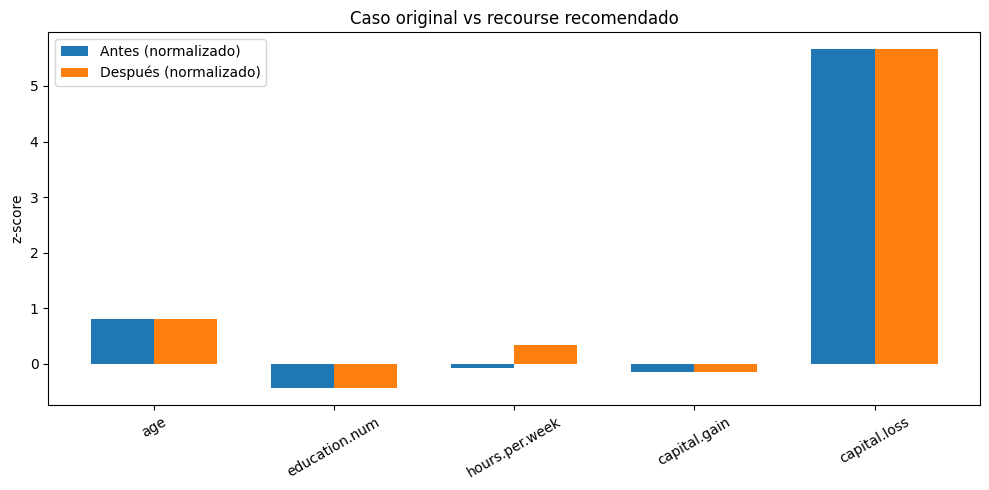

In [12]:
# ============================================
# CELDA 11. GRÁFICO ANTES VS DESPUÉS
# ============================================

from sklearn.preprocessing import StandardScaler

plot_features = feature_names.copy()
before_vals = persona[plot_features].astype(float).values
after_vals = selected_candidato[plot_features].astype(float).values

scaler = StandardScaler()
scaler.fit(df[plot_features])

before_scaled = scaler.transform(pd.DataFrame([before_vals], columns=plot_features))[0]
after_scaled = scaler.transform(pd.DataFrame([after_vals], columns=plot_features))[0]

x = np.arange(len(plot_features))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, before_scaled, width, label="Antes (normalizado)")
plt.bar(x + width / 2, after_scaled, width, label="Después (normalizado)")
plt.xticks(x, plot_features, rotation=30)
plt.ylabel("z-score")
plt.title("Caso original vs recourse recomendado")
plt.legend()
plt.tight_layout()
plt.show()

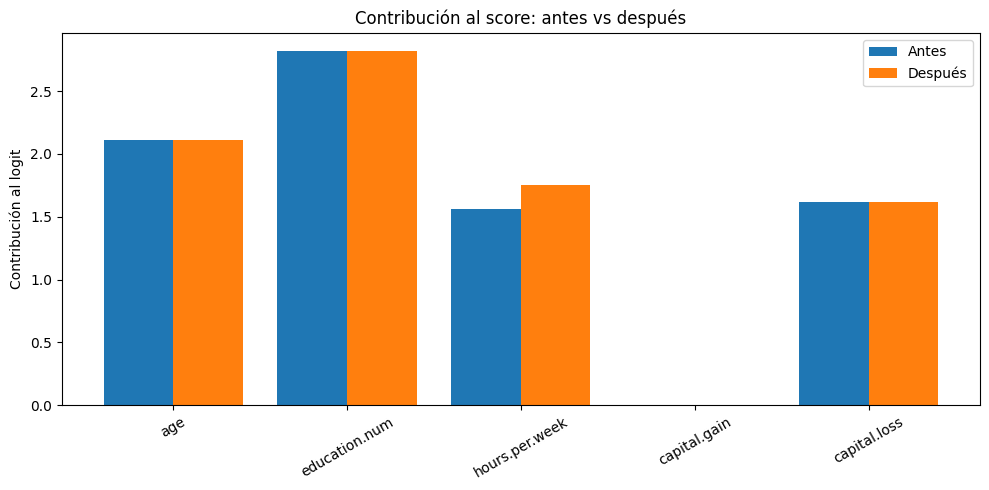

In [13]:
# ============================================
# CELDA 11B. CONTRIBUCIONES AL SCORE ANTES VS DESPUÉS
# ============================================

contrib_before = before_contrib.set_index("feature")["contribution"]
contrib_after = after_contrib.set_index("feature")["contribution"]
common_features = [f for f in contrib_before.index if f != "INTERCEPT"]

x = np.arange(len(common_features))

plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, contrib_before[common_features], 0.4, label="Antes")
plt.bar(x + 0.2, contrib_after[common_features], 0.4, label="Después")
plt.xticks(x, common_features, rotation=30)
plt.ylabel("Contribución al logit")
plt.title("Contribución al score: antes vs después")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Extensión temporal: el recourse puede vencerse

Hasta acá verificamos si el recourse funciona **hoy**. Ahora agregamos una pregunta más realista: **¿sigue funcionando si pasa el tiempo y cambia el contexto?**

En Adult Income no tenemos una dimensión temporal observada por persona, así que esta sección hace una simulación pedagógica con el mismo espacio de variables del modelo. La idea es mostrar que una recomendación puede cruzar el umbral hoy, pero perder efectividad si parte de la mejora no se sostiene.

In [14]:
# ============================================
# CELDA 12. CHEQUEO TEMPORAL DEL RECOURSE
# ============================================

def temporal_check(candidato_row, original_row, model, feature_names,
                   years_passed=1,
                   hours_drop=5,
                   capital_gain_drop=500):
    """
    Simula un escenario futuro adverso pero coherente con Adult Income:
    - pasa el tiempo (age aumenta);
    - la persona no logra sostener todas las horas extra trabajadas;
    - una mejora transitoria en capital.gain puede reducirse.
    """
    future = candidato_row.copy()

    future["age"] = min(float(future["age"] + years_passed), float(df["age"].max()))
    future["hours.per.week"] = max(float(original_row["hours.per.week"]), float(future["hours.per.week"] - hours_drop))
    future["capital.gain"] = max(0.0, float(future["capital.gain"] - capital_gain_drop))

    p_now = float(model.predict_proba(pd.DataFrame([candidato_row[feature_names]]))[0, 1])
    p_future = float(model.predict_proba(pd.DataFrame([future[feature_names]]))[0, 1])

    return round(p_now, 4), round(p_future, 4), future

p_now, p_future, future_case = temporal_check(
    selected_candidato,
    persona,
    model,
    feature_names,
    years_passed=1,
    hours_drop=5,
    capital_gain_drop=500
)

print("Probabilidad justo después del recourse:", p_now)
print("Probabilidad en un escenario futuro adverso:", p_future)
print("¿El recourse sigue por encima del umbral?", "Sí" if p_future >= 0.5 else "No")
print()
print("Caso futuro simulado:")
display(future_case.to_frame(name="future_value"))

Probabilidad justo después del recourse: 0.548
Probabilidad en un escenario futuro adverso: 0.5102
¿El recourse sigue por encima del umbral? Sí

Caso futuro simulado:


,future_value
age,50
education.num,9
hours.per.week,40
capital.gain,0
capital.loss,2377


## Chequeo temporal del *recourse* e interpretación de los resultados

La lectura metodológica es directa:

- **`p_now`** indica si la recomendación logra cambiar la predicción en el presente.
- **`p_future`** muestra qué pasa cuando parte de esa mejora se deteriora con el tiempo.

En esta adaptación al dataset Adult Income, el shock temporal no usa variables ajenas al flujo del notebook. Solo modifica atributos ya modelados:

- `age` aumenta porque el tiempo pasa;
- `hours.per.week` puede caer si la persona no sostiene el esfuerzo extra;
- `capital.gain` puede reducirse si la mejora económica era transitoria.

Si `p_future` queda por debajo de 0.5, el recourse **vence**: fue suficiente para hoy, pero no construyó un margen robusto. Si sigue por encima de 0.5, entonces la recomendación no solo cambia la decisión, sino que además deja algo de colchón frente a un escenario adverso.

Eso cierra la sección principal del taller con una idea importante: un buen recourse no debería evaluarse solo por su éxito instantáneo, sino también por su **estabilidad temporal**.

## 13. Introducir plausibilidad y acción parcial

En la vida real, no basta con que un cambio sea matemáticamente suficiente. También debería ser:

- **plausible**,
- **consistente con el contexto**,
- y en algunos casos solo **parcialmente accionable**.

Aquí añadimos restricciones heurísticas, no causales, para ilustrar la idea:
- la educación no puede subir demasiado de golpe,
- una gran mejora en `capital.gain` debería venir acompañada de alguna mejora en `hours.per.week` o `education.num`,
- y un cambio fuerte en `capital.loss` no debería aparecer como magia de una noche.


In [15]:
# ============================================
# CELDA 13. RESTRICCIONES DE PLAUSIBILIDAD
# ============================================

rejected = actionable_preview.copy()

def is_plausible_candidate(original, candidato):
    education_delta = float(candidato["education.num"] - original["education.num"])
    hours_delta = float(candidato["hours.per.week"] - original["hours.per.week"])
    capital_gain_delta = float(candidato["capital.gain"] - original["capital.gain"])

    rules = []

    rules.append(education_delta <= 2)
    rules.append(hours_delta <= 20)
    rules.append(not (capital_gain_delta > 4000 and hours_delta < 5 and education_delta < 1))

    return all(rules)


def find_recourse_filtered(persona_row, model, feature_names, actionable_features, plausibility_fn=None):
    value_grid = {
        f: build_candidate_values(float(persona_row[f]), cfg)
        for f, cfg in actionable_features.items()
    }

    candidates = []

    for values in product(*[value_grid[f] for f in actionable_features.keys()]):
        candidato = persona_row.copy()

        for f, v in zip(actionable_features.keys(), values):
            candidato[f] = v

        if plausibility_fn is not None and not plausibility_fn(persona_row, candidato):
            continue

        x_candidato = pd.DataFrame([candidato[feature_names]])
        prob = model.predict_proba(x_candidato)[0, 1]
        pred = int(prob >= 0.5)

        if pred == 1:
            total_cost, cost_detail, changed_features = recourse_cost(persona_row, candidato, actionable_features)

            candidates.append({
                "prob_approve": round(float(prob), 4),
                "total_cost": total_cost,
                "candidate": candidato.copy(),
                "cost_detail": cost_detail,
                "changed_features": changed_features
            })

    if len(candidates) == 0:
        return None, []

    candidates = sorted(candidates, key=lambda x: (x["total_cost"], -x["prob_approve"]))
    return candidates[0], candidates


plausible_recourse, plausible_candidates = find_recourse_filtered(
    persona_row=persona,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate
)

print("Número de soluciones plausibles encontradas:", len(plausible_candidates))
print("\nMejor solución plausible:")
print(plausible_recourse)


Número de soluciones plausibles encontradas: 456

Mejor solución plausible:
{'prob_approve': 0.548, 'total_cost': 1.5, 'candidate': age                 49
education.num        9
hours.per.week      45
capital.gain         0
capital.loss      2377
Name: 108, dtype: int64, 'cost_detail': {'education.num': 0.0, 'hours.per.week': 1.0, 'capital.gain': 0.0, 'sparsity_penalty': 0.5}, 'changed_features': ['hours.per.week']}


## Restricciones de plausibilidad y búsqueda de *recourse* filtrado

En esta sección agregamos un filtro extra: no alcanza con que el cambio haga cruzar el umbral del modelo, también debe ser **plausible** para el contexto del taller sobre Adult Income.

Las reglas heurísticas están alineadas con las variables reales del notebook:

1. `education.num` no debería subir más de 2 niveles de una vez.
2. `hours.per.week` no debería aumentar en más de 20 horas de golpe.
3. Un aumento muy grande de `capital.gain` solo se acepta si viene acompañado de una mejora laboral o educativa mínima.

El resultado observado es importante: aun después del filtro quedaron **456 soluciones plausibles**, y la mejor solución plausible **coincide con la mejor solución libre**.

En concreto, la recomendación sigue siendo aumentar `hours.per.week` de 40 a 45, con **costo total 1.5** y **probabilidad de aprobación 0.548**. Eso es una buena señal metodológica: el recourse no dependía de un cambio raro o difícil de defender, sino de una modificación simple que también sobrevive al filtro de plausibilidad.

La lectura conceptual es fuerte: imponer plausibilidad **reduce el espacio de búsqueda**, pero en este caso no destruye la mejor recomendación. Entonces el recourse encontrado no solo es matemáticamente válido, sino también razonablemente defendible para la narrativa del taller.


## 14. Evaluación en lote sobre varios casos rechazados

Ahora pasamos de un solo caso a una pequeña **mini-población** de casos rechazados.

Esto nos permite responder preguntas como:
- ¿con qué frecuencia encontramos recourse?
- ¿qué tan costoso suele ser?
- ¿cuánto sube, en promedio, la probabilidad?
- ¿cuánto cambia el panorama cuando imponemos plausibilidad?


In [16]:
# ============================================
# CELDA 14. EVALUACIÓN EN LOTE
# ============================================

def evaluate_recourse_batch(rejected_df, model, feature_names, actionable_features, plausibility_fn=None, max_cases=40):
    rows = []

    sample_df = rejected_df.head(max_cases).copy()

    for idx, row in sample_df.iterrows():
        persona_row = row[feature_names].copy()
        base_prob = float(model.predict_proba(pd.DataFrame([persona_row]))[0, 1])

        best, _ = find_recourse_filtered(
            persona_row=persona_row,
            model=model,
            feature_names=feature_names,
            actionable_features=actionable_features,
            plausibility_fn=plausibility_fn
        )

        result = {
            "index": idx,
            "base_prob": base_prob,
            "found_recourse": best is not None,
            "age": persona_row["age"],
            "education.num": persona_row["education.num"],
            "hours.per.week": persona_row["hours.per.week"]
        }

        if best is not None:
            result["new_prob"] = best["prob_approve"]
            result["prob_gain"] = best["prob_approve"] - base_prob
            result["total_cost"] = best["total_cost"]
        else:
            result["new_prob"] = np.nan
            result["prob_gain"] = np.nan
            result["total_cost"] = np.nan

        rows.append(result)

    return pd.DataFrame(rows)

batch_free = evaluate_recourse_batch(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=None,
    max_cases=40
)

batch_plausible = evaluate_recourse_batch(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate,
    max_cases=40
)

summary_batch = pd.DataFrame([
    {
        "scenario": "Libre",
        "n_cases": len(batch_free),
        "success_rate": batch_free["found_recourse"].mean(),
        "avg_cost_successes": batch_free.loc[batch_free["found_recourse"], "total_cost"].mean(),
        "avg_prob_gain_successes": batch_free.loc[batch_free["found_recourse"], "prob_gain"].mean()
    },
    {
        "scenario": "Plausible",
        "n_cases": len(batch_plausible),
        "success_rate": batch_plausible["found_recourse"].mean(),
        "avg_cost_successes": batch_plausible.loc[batch_plausible["found_recourse"], "total_cost"].mean(),
        "avg_prob_gain_successes": batch_plausible.loc[batch_plausible["found_recourse"], "prob_gain"].mean()
    }
])

display(summary_batch)


,scenario,n_cases,success_rate,avg_cost_successes,avg_prob_gain_successes
0,Libre,40,1.0,1.5,0.048585
1,Plausible,40,1.0,1.5,0.048585


## Interpretación de la evaluación en lote

En los **40 casos rechazados evaluados**, el recourse funcionó en el **100%** de los casos tanto en el escenario **Libre** como en el escenario **Plausible**.

- En ambos escenarios, la **tasa de éxito** fue de **1.0**.
- El **costo promedio** de las soluciones exitosas fue exactamente **1.5**.
- La **ganancia promedio de probabilidad** también fue igual en ambos casos: **0.048585**.

La lectura metodológica es fuerte: en esta muestra, imponer restricciones de plausibilidad **no empeoró** el recourse. No bajó la tasa de éxito, no subió el costo promedio y tampoco redujo la mejora promedio en la probabilidad de aprobación.

Eso sugiere que, para estos 40 casos, las soluciones encontradas por la búsqueda libre ya eran razonablemente plausibles. En otras palabras, el recourse no dependía de recomendaciones extremas o poco defendibles, sino de cambios que siguen siendo viables incluso después de aplicar el filtro heurístico.

Desde la narrativa del taller, esto fortalece una idea importante: el recourse hallado no solo es **matemáticamente efectivo**, sino también **compatible con restricciones simples de plausibilidad y acción parcial**.

### Visualizar la distribución de costos en lote

Después del resumen agregado, conviene mirar la **distribución** de costos. Así vemos si la plausibilidad solo cambia el promedio o si desplaza toda la masa hacia soluciones más caras.

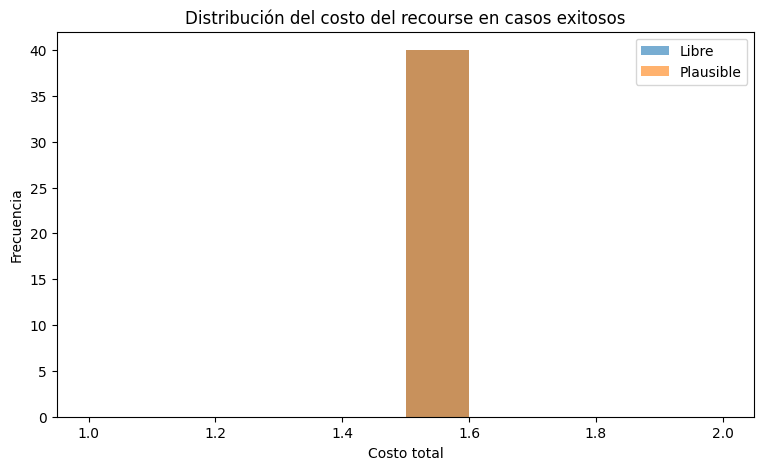

### Interpretación de la distribución de costos en lote
- En el escenario libre, la tasa de éxito es **100.00%**.
- En el escenario plausible, la tasa de éxito es **100.00%**.
- El costo promedio entre los éxitos se mantiene en **1.500** tanto en el escenario libre como en el plausible.
- La ganancia promedio de probabilidad también se mantiene igual: **0.049** en ambos escenarios.
- El histograma muestra que las dos distribuciones están completamente superpuestas, sin desplazamiento visible ni mayor dispersión en el escenario plausible.
- En esta muestra, imponer plausibilidad no encarece el recourse ni elimina soluciones exitosas: las recomendaciones libres ya eran razonablemente plausibles.
- Metodológicamente, esto refuerza que el recourse encontrado es estable: sigue funcionando con el mismo nivel de esfuerzo incluso después de aplicar restricciones heurísticas.

In [17]:
# ============================================
# CELDA 15. VISUALIZAR COSTOS EN LOTE
# ============================================

plt.figure(figsize=(9, 5))
plt.hist(batch_free.loc[batch_free["found_recourse"], "total_cost"].dropna(), alpha=0.6, label="Libre")
plt.hist(batch_plausible.loc[batch_plausible["found_recourse"], "total_cost"].dropna(), alpha=0.6, label="Plausible")
plt.title("Distribución del costo del recourse en casos exitosos")
plt.xlabel("Costo total")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

def interpret_batch_results(summary_batch):
    free_row = summary_batch[summary_batch["scenario"] == "Libre"].iloc[0]
    plausible_row = summary_batch[summary_batch["scenario"] == "Plausible"].iloc[0]

    text = []
    text.append("### Interpretación de la distribución de costos en lote")
    text.append(f"- En el escenario libre, la tasa de éxito es **{free_row['success_rate']:.2%}**.")
    text.append(f"- En el escenario plausible, la tasa de éxito es **{plausible_row['success_rate']:.2%}**.")
    text.append(f"- El costo promedio entre los éxitos se mantiene en **{free_row['avg_cost_successes']:.3f}** tanto en el escenario libre como en el plausible.")
    text.append(f"- La ganancia promedio de probabilidad también se mantiene igual: **{free_row['avg_prob_gain_successes']:.3f}** en ambos escenarios.")
    text.append("- El histograma muestra que las dos distribuciones están completamente superpuestas, sin desplazamiento visible ni mayor dispersión en el escenario plausible.")
    text.append("- En esta muestra, imponer plausibilidad no encarece el recourse ni elimina soluciones exitosas: las recomendaciones libres ya eran razonablemente plausibles.")
    text.append("- Metodológicamente, esto refuerza que el recourse encontrado es estable: sigue funcionando con el mismo nivel de esfuerzo incluso después de aplicar restricciones heurísticas.")

    display(Markdown("\n".join(text)))

interpret_batch_results(summary_batch)


## 16. Robustez temporal en lote

Una buena recomendación no solo debe funcionar **hoy**. También conviene preguntarse:

- ¿sigue funcionando si el contexto cambia un poco?
- ¿se mantiene la aprobación después de un shock razonable?
- ¿o era una solución demasiado frágil?

Aquí evaluamos la robustez temporal de los recourses plausibles.


In [18]:
# ============================================
# CELDA 16. ROBUSTEZ TEMPORAL EN LOTE
# ============================================

def collect_successful_recourse_objects(rejected_df, model, feature_names, actionable_features, plausibility_fn=None, max_cases=40):
    rows = []
    sample_df = rejected_df.head(max_cases).copy()

    for idx, row in sample_df.iterrows():
        persona_row = row[feature_names].copy()

        best, _ = find_recourse_filtered(
            persona_row=persona_row,
            model=model,
            feature_names=feature_names,
            actionable_features=actionable_features,
            plausibility_fn=plausibility_fn
        )

        if best is not None:
            rows.append({
                "index": idx,
                "person": persona_row,
                "recourse": best["candidate"],
                "prob_after": best["prob_approve"],
                "cost": best["total_cost"]
            })

    return rows

successful_plausible = collect_successful_recourse_objects(
    rejected_df=rejected,
    model=model,
    feature_names=feature_names,
    actionable_features=actionable_features,
    plausibility_fn=is_plausible_candidate,
    max_cases=40
)

temporal_rows = []

for item in successful_plausible:
    p_now, p_future, future_case = temporal_check(
        item["recourse"],
        item["person"],
        model,
        feature_names,
        years_passed=1,
        hours_drop=5,
        capital_gain_drop=500
    )

    temporal_rows.append({
        "index": item["index"],
        "prob_after": p_now,
        "prob_future": p_future,
        "drop": p_now - p_future,
        "remains_approved": p_future >= 0.5,
        "cost": item["cost"]
    })

temporal_df = pd.DataFrame(temporal_rows)
display(temporal_df.head())

if len(temporal_df) > 0:
    temporal_summary = pd.DataFrame([{
        "n_successful_recourse": len(temporal_df),
        "share_remaining_approved": temporal_df["remains_approved"].mean(),
        "avg_probability_drop": temporal_df["drop"].mean()
    }])
else:
    temporal_summary = pd.DataFrame([{
        "n_successful_recourse": 0,
        "share_remaining_approved": np.nan,
        "avg_probability_drop": np.nan
    }])

display(temporal_summary)


,index,prob_after,prob_future,drop,remains_approved,cost
0,108,0.5480,0.5102,0.0378,True,1.5
1,23359,0.5479,0.5101,0.0378,True,1.5
2,5628,0.5476,0.5099,0.0377,True,1.5
3,17107,0.5471,0.5093,0.0378,True,1.5
4,17642,0.5471,0.5093,0.0378,True,1.5


,n_successful_recourse,share_remaining_approved,avg_probability_drop
0,40,0.8,0.040853


### Interpretar la robustez temporal

No alcanza con mostrar histogramas: también hay que traducirlos a una lectura pedagógica. Esta sección resume cuántos recourses plausibles sobreviven al shock y qué tan grande es la caída promedio de probabilidad.

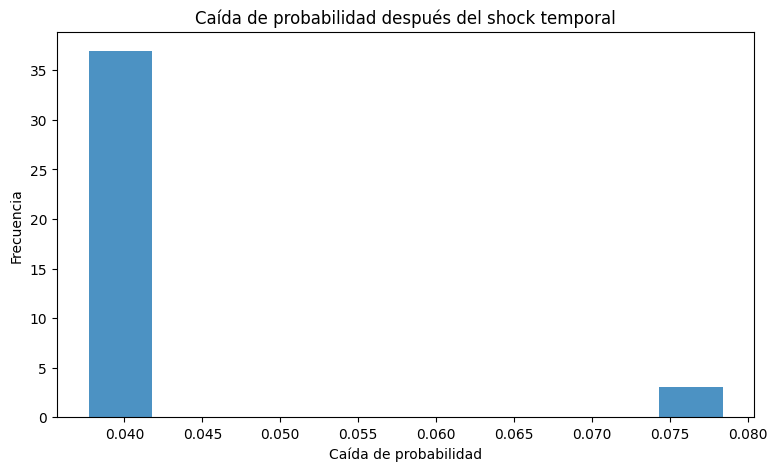

In [19]:
# ============================================
# CELDA 17. INTERPRETAR ROBUSTEZ TEMPORAL
# ============================================

if len(temporal_df) > 0:
    plt.figure(figsize=(9, 5))
    plt.hist(temporal_df["drop"], alpha=0.8)
    plt.title("Caída de probabilidad después del shock temporal")
    plt.xlabel("Caída de probabilidad")
    plt.ylabel("Frecuencia")
    plt.show()

def interpret_temporal_results(temporal_summary):
    row = temporal_summary.iloc[0]

    text = []
    text.append("### Interpretación temporal")

    if row["n_successful_recourse"] == 0:
        text.append("- No hubo recourses plausibles exitosos para evaluar robustez temporal.")
    else:
        text.append(f"- Se evaluaron **{int(row['n_successful_recourse'])}** casos con recourse plausible exitoso.")
        text.append(f"- La proporción que se mantiene aprobada después del shock es **{row['share_remaining_approved']:.2%}**.")
        text.append(f"- La caída promedio de probabilidad es **{row['avg_probability_drop']:.3f}**.")
        text.append("- Si muchas recomendaciones dejan de funcionar tras un pequeño shock, el recourse es frágil.")
        text.append("- Si la mayoría sobrevive, eso sugiere que las recomendaciones no solo cruzan el umbral, sino que crean cierto margen de seguridad.")

    display(Markdown("\n".join(text)))

interpret_temporal_results(temporal_summary)


## 17. Contrastar el recourse manual con DiCE

Hasta acá construimos recourse manual, controlado y totalmente interpretable. Ahora usamos **DiCE** como punto de comparación: no para reemplazar el análisis anterior, sino para ver si una librería estándar llega a recomendaciones parecidas bajo las mismas restricciones accionables.

In [20]:
# ============================================
# CELDA 18. DICE SOBRE EL NOTEBOOK ACTUAL
# ============================================

!pip -q install dice-ml

import dice_ml

# 1. Crear la instancia a explicar
query_instance = pd.DataFrame([persona[feature_names]])

# 2. Definir rangos permitidos a partir de tus reglas de actionability
permitted_range = {
    f: [cfg["min_value"], cfg["max_value"]]
    for f, cfg in actionable_features.items()
}

# 3. Definir el objeto de datos para DiCE
# Como todas tus variables son numéricas, las tratamos como continuas
data_dice = dice_ml.Data(
    dataframe=df[feature_names + ["ingreso_alto"]].copy(),
    continuous_features=feature_names,
    outcome_name="ingreso_alto"
)

# 4. Envolver tu modelo sklearn ya entrenado
model_dice = dice_ml.Model(
    model=model,
    backend="sklearn"
)

# 5. Crear el generador de contrafactuales
# Para mantener reproducibilidad en DiCE usamos la convención del repo
# y pasamos `random_seed=42` en la generación de contrafactuales.
random_state = 42
np.random.seed(random_state)
# Puedes probar "random" o "genetic"; aquí usamos "genetic"
# porque suele dar soluciones más cuidadas
exp = dice_ml.Dice(
    data_dice,
    model_dice,
    method="genetic"
)

# 6. Generar contrafactuales
dice_result = exp.generate_counterfactuals(
    query_instances=query_instance,
    total_CFs=4,
    desired_class="opposite",
    features_to_vary=list(actionable_features.keys()),
    permitted_range=permitted_range,
    random_seed=random_state
)

# 7. Visualizar solo los cambios
dice_result.visualize_as_dataframe(show_only_changes=True)

# 8. Extraer DataFrame final para usarlo después
dice_df = dice_result.cf_examples_list[0].final_cfs_df.copy()

print("Contrafactuales generados por DiCE:")
display(dice_df)


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  1.63it/s]


100%|██████████| 1/1 [00:00<00:00,  1.62it/s]

Query instance (original outcome : 0)


,age,education.num,hours.per.week,capital.gain,capital.loss,ingreso_alto
0,49,9,40,0,2377,0



Diverse Counterfactual set (new outcome: 1)


,age,education.num,hours.per.week,capital.gain,capital.loss,ingreso_alto
0,-,-,45,-,-,1
0,-,-,50,-,-,1
0,-,-,55,-,-,1


Contrafactuales generados por DiCE:


,age,education.num,hours.per.week,capital.gain,capital.loss,ingreso_alto
0,49,9,45,0,2377,1
0,49,9,50,0,2377,1
0,49,9,55,0,2377,1


### Evaluar los contrafactuales de DiCE con la misma métrica

Comparar métodos sin una métrica común es trampa. Por eso, a cada contrafactual generado por DiCE le calculamos el mismo costo manual usado en el recourse propio, así la comparación queda en igualdad de condiciones.

In [21]:
# ============================================
# CELDA 19. EVALUAR LOS CF DE DICE CON TU MÉTRICA
# ============================================

dice_eval_rows = []

if dice_df is not None and len(dice_df) > 0:
    for i, (_, row) in enumerate(dice_df.iterrows(), start=1):
        candidato = row[feature_names].copy()

        # Probabilidad con tu modelo original
        prob_candidato = float(model.predict_proba(pd.DataFrame([candidato]))[0, 1])

        # Costo usando tu función manual
        total_cost, cost_detail, changed_features = recourse_cost(
            original=persona,
            candidato=candidato,
            actionable_features=actionable_features
        )

        # Resumen de cambios
        changed_features = [
            f for f in feature_names
            if abs(float(candidato[f] - persona[f])) > 1e-9
        ]

        dice_eval_rows.append({
            "cf_rank": i,
            "prob_approve": round(prob_candidato, 4),
            "total_cost_manual_metric": float(total_cost),
            "n_changed_features": len(changed_features),
            "changed_features": ", ".join(changed_features),
            "cost_detail": str(cost_detail)
        })

    dice_eval_df = pd.DataFrame(dice_eval_rows)
    display(dice_eval_df)
else:
    print("DiCE no devolvió contrafactuales.")

,cf_rank,prob_approve,total_cost_manual_metric,n_changed_features,changed_features,cost_detail
0,1,0.5480,1.5,1,hours.per.week,"{'education.num': 0.0, 'hours.per.week': 1.0, ..."
1,2,0.5956,2.5,1,hours.per.week,"{'education.num': 0.0, 'hours.per.week': 2.0, ..."
2,3,0.6415,3.5,1,hours.per.week,"{'education.num': 0.0, 'hours.per.week': 3.0, ..."


### Comparar la mejor solución manual con la mejor solución de DiCE

Acá ponemos ambas estrategias lado a lado. La idea no es coronar un ganador absoluto, sino observar si DiCE reproduce una solución parecida o si encuentra un camino distinto con otro costo y otra probabilidad final.

In [22]:
# ============================================
# CELDA 20. COMPARACIÓN MANUAL VS DICE
# ============================================

comparison_rows = []

# Mejor solución manual
if best_recourse is not None:
    comparison_rows.append({
        "method": "Manual grid search",
        "prob_approve": best_recourse["prob_approve"],
        "total_cost": float(best_recourse["total_cost"]),
        "n_changed_features": int(sum(
            abs(float(best_recourse["candidate"][f] - persona[f])) > 1e-9
            for f in feature_names
        ))
    })

# Mejor solución de DiCE según tu métrica de costo
if "dice_eval_df" in globals() and len(dice_eval_df) > 0:
    best_dice_idx = dice_eval_df["total_cost_manual_metric"].idxmin()
    best_dice_row = dice_eval_df.loc[best_dice_idx]

    comparison_rows.append({
        "method": "DiCE",
        "prob_approve": best_dice_row["prob_approve"],
        "total_cost": best_dice_row["total_cost_manual_metric"],
        "n_changed_features": best_dice_row["n_changed_features"]
    })

comparison_methods_df = pd.DataFrame(comparison_rows)
display(comparison_methods_df)

,method,prob_approve,total_cost,n_changed_features
0,Manual grid search,0.548,1.5,1
1,DiCE,0.548,1.5,1


### Inspeccionar exactamente qué cambia en el mejor contrafactual de DiCE

Después de comparar métricas globales, conviene bajar al detalle. Esta tabla muestra variable por variable qué recomienda cambiar DiCE respecto del caso original para que la comparación no quede en números abstractos.

In [23]:
# ============================================
# CELDA 21. RESUMEN HUMANO DEL MEJOR CF DE DICE
# ============================================

if "dice_eval_df" in globals() and len(dice_eval_df) > 0:
    best_dice_idx = dice_eval_df["total_cost_manual_metric"].idxmin()
    best_dice_candidato = dice_df.iloc[best_dice_idx][feature_names].copy()

    summary_rows_dice = []
    for f in feature_names:
        summary_rows_dice.append({
            "feature": f,
            "original": persona[f],
            "dice_recommended": best_dice_candidato[f],
            "delta": round(float(best_dice_candidato[f] - persona[f]), 3)
        })

    summary_dice_df = pd.DataFrame(summary_rows_dice)
    display(summary_dice_df)

    print("Probabilidad original:",
          round(float(model.predict_proba(pd.DataFrame([persona]))[0, 1]), 4))
    print("Probabilidad con mejor CF de DiCE:",
          round(float(model.predict_proba(pd.DataFrame([best_dice_candidato]))[0, 1]), 4))
else:
    print("No hay contrafactuales de DiCE para resumir.")

,feature,original,dice_recommended,delta
0,age,49,49,0.0
1,education.num,9,9,0.0
2,hours.per.week,40,45,5.0
3,capital.gain,0,0,0.0
4,capital.loss,2377,2377,0.0


Probabilidad original: 0.4994
Probabilidad con mejor CF de DiCE: 0.548
